# Superstore Data Analytics Project

## Objective:
Analyze business performance using sales data to identify:
- Profit drivers
- Loss areas
- Growth opportunities
- Operational inefficiencies

## Tools:
Python, Pandas, Matplotlib, Seaborn, Power BI

## Workflow:
Data Ingestion → Cleaning → Transformation → Feature Engineering → 
EDA → KPI Creation → Business Analysis → Visualization → Dashboarding


## Business Questions

1. Which categories generate the highest profit?
2. Which regions are loss-making?
3. How does discount impact profit?
4. Which customer segment is most profitable?
5. What is the yearly sales growth trend?
6. Which products generate the highest losses and profits?
7. What is the average delivery time?
8. Which category has highest operational inefficiency?


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

from config import DATA_DIR,PLOTS_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
file_path = os.path.join(DATA_DIR, 'Sample - Superstore.csv')
data = pd.read_csv(file_path, encoding='latin1')

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.shape

(9994, 21)

In [5]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
data['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [12]:
data['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [13]:
date_cols = ['Order Date','Ship Date']
data[date_cols] = data[date_cols].apply(pd.to_datetime)

In [14]:
(data['Quantity']>0).all()

True

In [15]:
data['Order year'] = data['Order Date'].dt.year
data['Delivery Days'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Profit Margin'] = (data["Profit"]/data["Sales"]) * 100

In [16]:
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
avg_delivery = data["Delivery Days"].mean()
order_count = data["Order ID"].nunique()
profit_margin = (total_profit / total_sales) * 100


In [17]:
data.groupby("Category")["Profit"].sum().sort_values(ascending=False)


Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [18]:
data.groupby("Region")["Profit"].sum().sort_values()


Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64

In [19]:
data["Discount"].corr(data["Profit"])


-0.2194874563717678

In [20]:
data.groupby("Segment")["Profit"].sum().sort_values(ascending=False)


Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [21]:
sales_year = data.groupby("Order year")["Sales"].sum()
sales_year
sales_year.pct_change()*100


Order year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64

In [22]:
data.groupby("Product Name")["Profit"].sum().sort_values().head(5)
data.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(5)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

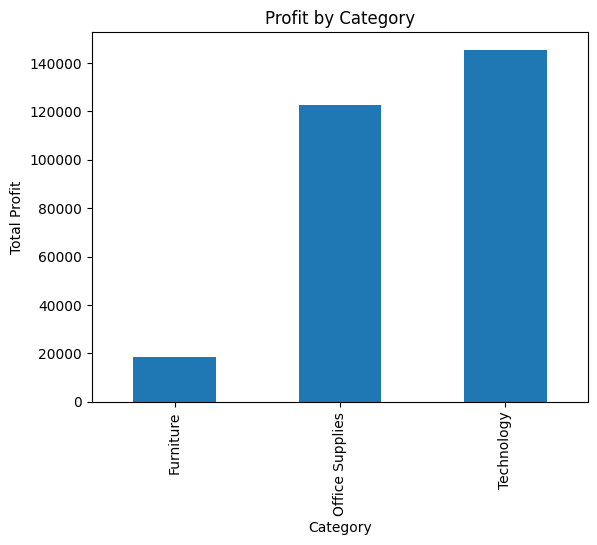

In [24]:
plt.figure()
data.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.savefig(os.path.join(PLOTS_DIR,"Total_profit_by_category.png"),dpi=500)
plt.show()


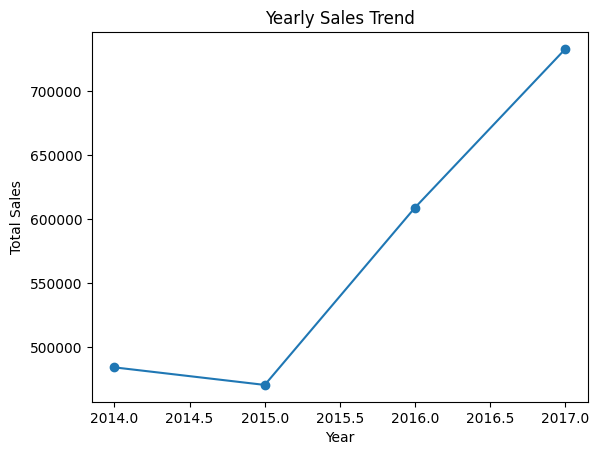

In [25]:
plt.figure()
sales_year.plot(marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.savefig(os.path.join(PLOTS_DIR,"Yearly_sales_trend.png"),dpi=500)
plt.show()


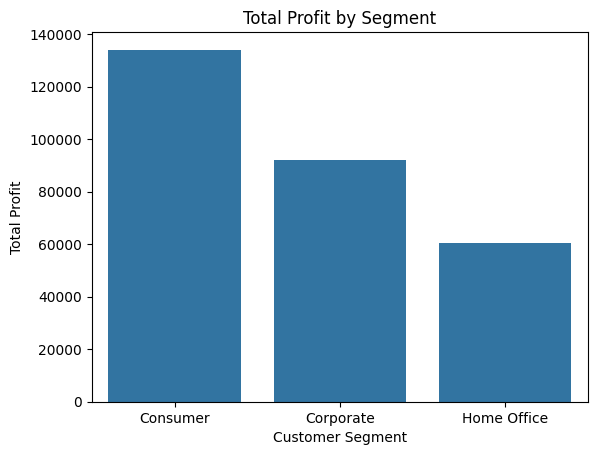

In [26]:
segment_profit = data.groupby("Segment", as_index=False)["Profit"].sum()

sns.barplot(data = segment_profit, x = "Segment", y = "Profit")
plt.title("Total Profit by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.savefig(os.path.join(PLOTS_DIR,"Total_profit_by_Segment.png"),dpi=500)
plt.show()


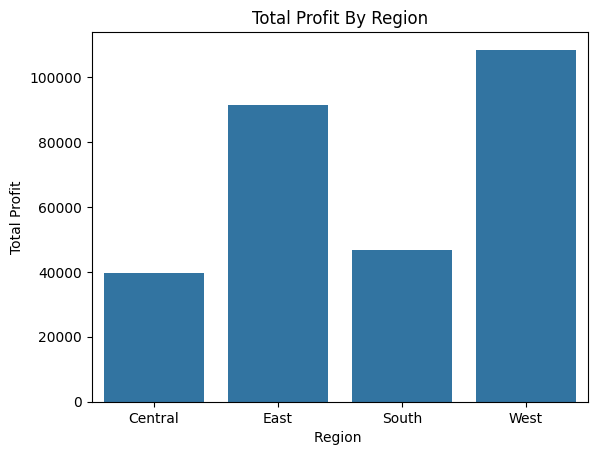

In [27]:
Region_profit = data.groupby('Region', as_index=False)['Profit'].sum()

sns.barplot(data = Region_profit, x = "Region", y = 'Profit')
plt.title("Total Profit By Region")
plt.xlabel("Region ")
plt.ylabel("Total Profit")
plt.savefig(os.path.join(PLOTS_DIR,"Total_profit_by_region.png"),dpi=500)
plt.show()

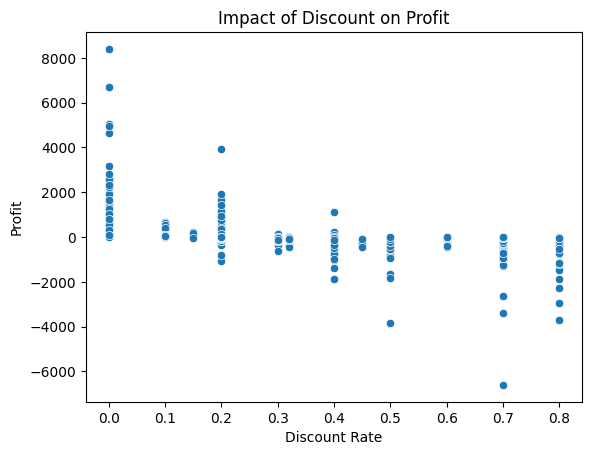

In [28]:
sns.scatterplot(data = data, x = 'Discount', y = 'Profit')
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount Rate")
plt.ylabel("Profit")
plt.savefig(os.path.join(PLOTS_DIR,"Impact_of_discount_on_profit.png"),dpi=500)
plt.show()

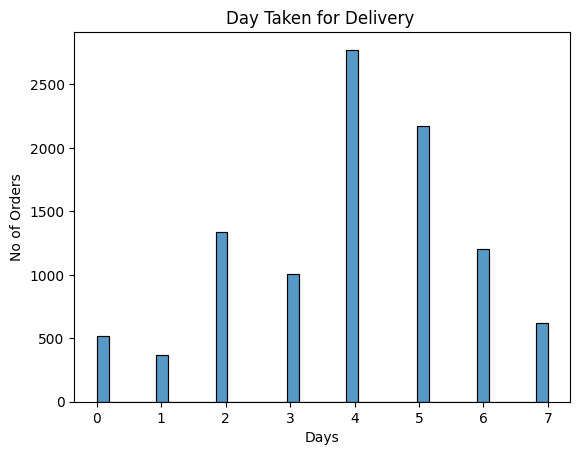

In [29]:
sns.histplot(data = data['Delivery Days'])
plt.title("Day Taken for Delivery ")
plt.xlabel("Days")
plt.ylabel("No of Orders")
plt.savefig(os.path.join(PLOTS_DIR,"Day_for_Delivery.png"),dpi=500)
plt.show()

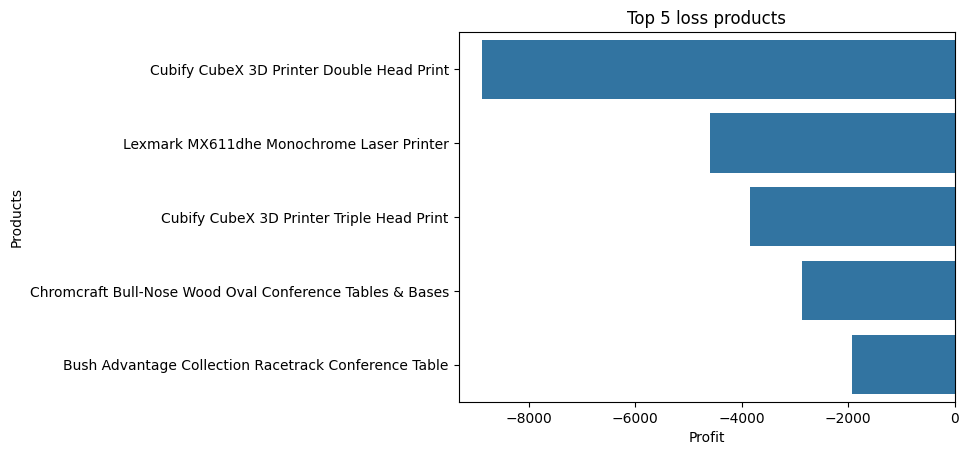

In [30]:
Top5_loss_product = data.groupby("Product Name",as_index = False)["Profit"].sum().sort_values(by = 'Profit', ascending=True).head(5)

sns.barplot(data = Top5_loss_product, y = 'Product Name', x = 'Profit' )
plt.title("Top 5 loss products")
plt.xlabel("Profit")
plt.ylabel("Products")
plt.savefig(os.path.join(PLOTS_DIR,"Top5_Loss_products.png"),dpi=500)
plt.show()

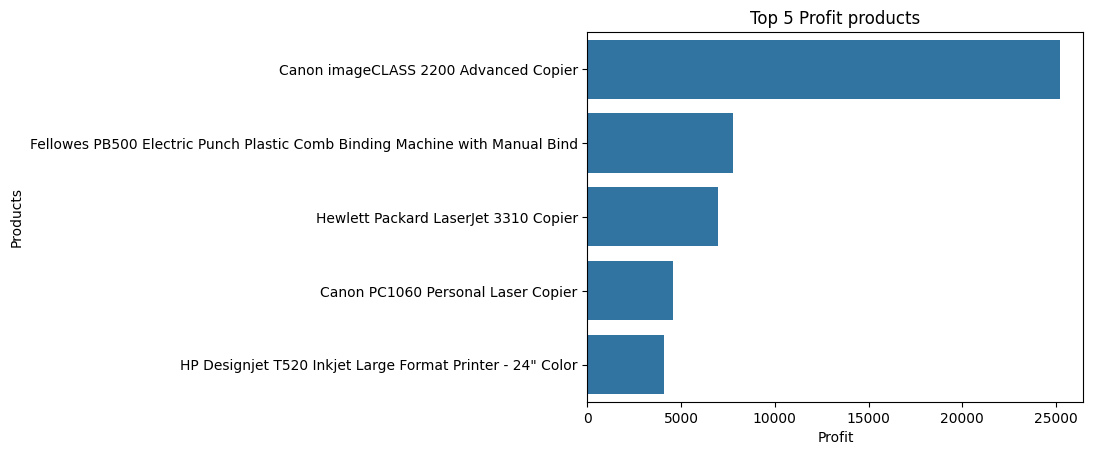

In [31]:
Top5_profit_product = data.groupby("Product Name",as_index = False)["Profit"].sum().sort_values(by = 'Profit', ascending=False).head(5)

sns.barplot(data = Top5_profit_product, y = 'Product Name', x = 'Profit' )
plt.title("Top 5 Profit products")
plt.xlabel("Profit")
plt.ylabel("Products")
plt.savefig(os.path.join(PLOTS_DIR,"Top5_profit_products.png"),dpi=500)
plt.show()

## Business Insights

- Technology category is the main profit driver  
- Certain regions operate at loss → cost/discount mismanagement  
- High discount negatively impacts profit  
- Corporate segment is most profitable  
- Some products generate consistent losses → should be removed  
- Delivery time impacts customer satisfaction & operations  


## Business Decisions

- Limit discounting strategy → apply margin-safe discount caps.
- Prioritize high-margin categories → focus marketing and inventory on profitable products.
- Optimize loss-making regions → improve logistics, supply chain, and operational costs.
- CFocus on profitable customer segments → target Corporate & Consumer with loyalty programs.
- Shift KPIs from sales to profit → management decisions should be profit-driven, not revenue-driven.
  
